## Phase 4 — Deep Dive Investigation

#### Problem Selected:
**"High Discounting is Silently Destroying Company Profitability"**

#### Why This Problem?
During Phase 2 EDA, we discovered 3 critical signals:
- Tables(-$17,725), Bookcases(-$3,472), Supplies (-$1,189) are making losses.
- Orders with 0% discount earn avg profit of $66.90
- Orders with 50%+ discount LOSE avg -$105.28 per order
- Central region has the worst profit margin at only 7.92%

#### Root Cause Analysis — 5 Dimensions:
1. At what exact discount % does profit turn negative?
2. Which categories are being over-discounted?
3. Which regions give the most aggressive discounts?
4. Is discounting actually increasing sales volume? (The big question)
5. What is the total financial damage done by excessive discounting?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(12,5)
plt.rcParams['font.size']=12

In [3]:
df=pd.read_csv(r"C:\Users\hites\Downloads\Superstore_cleaned.csv")
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print("Shape:", df.shape)

Shape: (9994, 26)


#### Finding Exact Discount Threshold

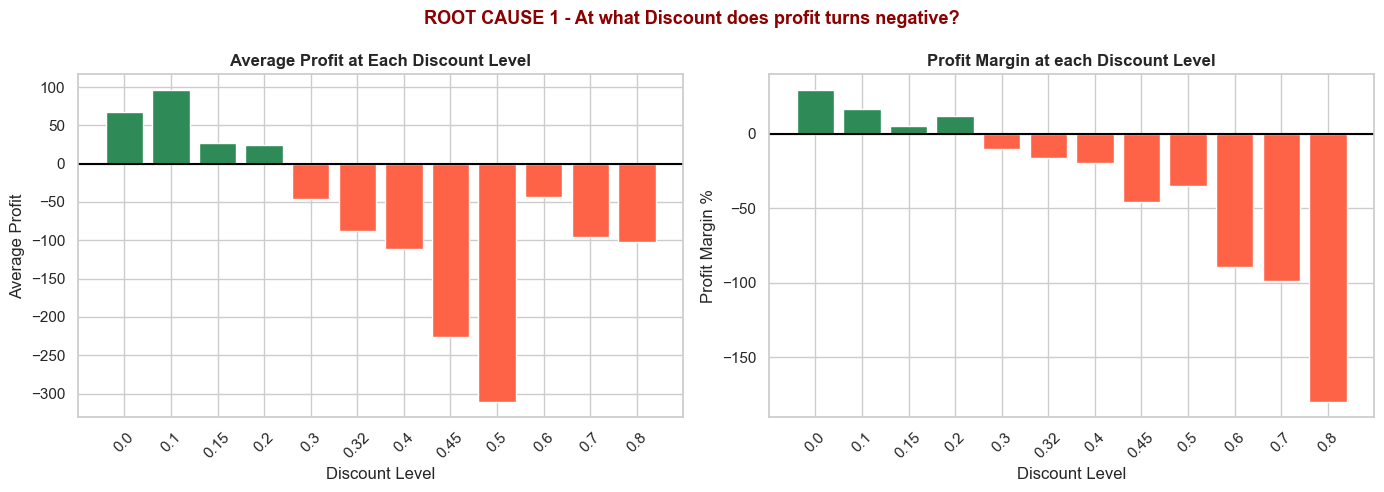

Finding : Profit turns Negative from discount level: 0.3
Total orders losing money: 1871
% of all orders losing money: 18.7 %
    Discount  Avg_Profit  Profit_Margin_%  Total_Orders
0       0.00   66.900292            29.51          4798
1       0.10   96.055074            16.61            94
2       0.15   27.288298             5.15            52
3       0.20   24.702572            11.82          3657
4       0.30  -45.679636           -10.05           227
5       0.32  -88.560656           -16.50            27
6       0.40 -111.927429           -19.81           206
7       0.45 -226.646464           -45.45            11
8       0.50 -310.703456           -34.80            66
9       0.60  -43.077212           -89.46           138
10      0.70  -95.874060           -98.66           418
11      0.80 -101.796797          -180.03           300


In [16]:
# Grp by dsicount level
discount_analysis=df.groupby('Discount').agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Orders=('Order ID', 'count'),
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum')
).reset_index()

discount_analysis['Profit_Margin_%']=(discount_analysis['Total_Profit']/discount_analysis['Total_Sales']*100).round(2)
fig,axes=plt.subplots(1,2,figsize=(14,5))

# C1 - Avg profit at each discount level
colors=['seagreen' if x>0 else 'tomato' for x in discount_analysis['Avg_Profit']]
axes[0].bar(discount_analysis['Discount'].astype(str), discount_analysis['Avg_Profit'], color=colors)
axes[0].axhline(0, color='black', linewidth=1.5)
axes[0].set_title('Average Profit at Each Discount Level', fontweight='bold')
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Average Profit')
axes[0].tick_params(axis='x', rotation=45)

# C2 - Profit MArgin at each discount level
colors2=['seagreen' if x>0 else 'tomato' for x in discount_analysis['Profit_Margin_%']]
axes[1].bar(discount_analysis['Discount'].astype(str), discount_analysis['Profit_Margin_%'], color=colors2)
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_title('Profit Margin at each Discount Level', fontweight='bold')
axes[1].set_xlabel('Discount Level')
axes[1].set_ylabel('Profit Margin %')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('ROOT CAUSE 1 - At what Discount does profit turns negative?', fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('Discount_threshold.png', dpi=150)
plt.show()

neg=discount_analysis[discount_analysis['Avg_Profit']<0]
print('='*55)
print('Finding : Profit turns Negative from discount level:', neg['Discount'].min())
print('Total orders losing money:', len(df[df['Profit']<0]))
print('% of all orders losing money:', round(len(df[df['Profit']<0])/len(df)*100,1),'%')
print('='*55)
print(discount_analysis[['Discount', 'Avg_Profit', 'Profit_Margin_%', 'Total_Orders']])

#### Which categories are over discounted?

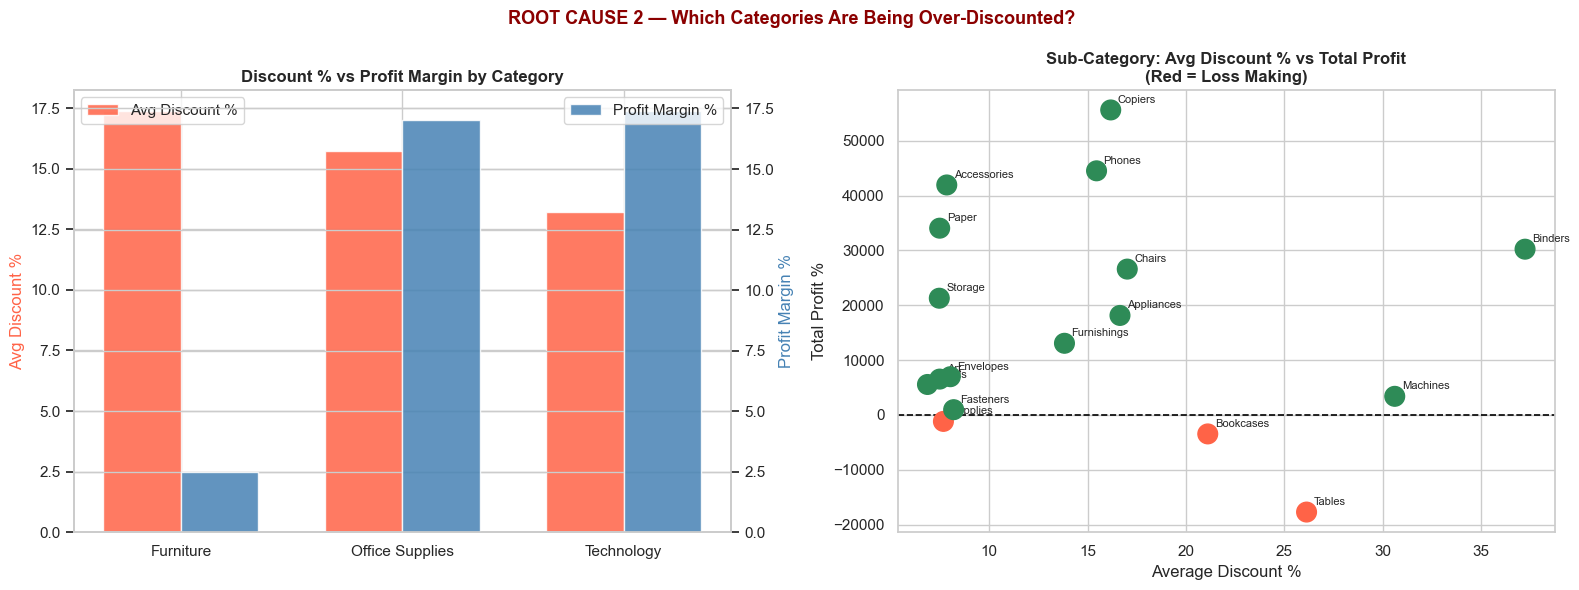

          Category  Avg_Discount_%  Profit_Margin_%  Total_Profit
0        Furniture           17.39             2.49    18451.2728
1  Office Supplies           15.73            17.04   122490.8008
2       Technology           13.23            17.40   145454.9481


In [17]:
# category level discount vs margin
cat_discount=df.groupby('Category').agg(
    Avg_Discount=('Discount', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum')
).reset_index()
cat_discount['Profit_Margin_%']=(cat_discount['Total_Profit']/cat_discount['Total_Sales']*100).round(2)
cat_discount['Avg_Discount_%']=(cat_discount['Avg_Discount']*100).round(2)

# sub-category level
subcat_discount=df.groupby('Sub-Category').agg(
    Avg_Discount=('Discount', 'mean'),
    Total_Profit=('Profit', 'sum')
).reset_index()
subcat_discount['Avg_Discount_%']=(subcat_discount['Avg_Discount']*100).round(2)
subcat_discount=subcat_discount.sort_values('Total_Profit')
fig,axes=plt.subplots(1,2,figsize=(16,6))

# Ch1 — Category: Discount % vs Profit Margin %
x=range(len(cat_discount))
width=0.35
axes[0].bar([i - width/2 for i in x], cat_discount['Avg_Discount_%'], width, label='Avg Discount %', color='tomato', alpha=0.85)
ax2 = axes[0].twinx()
ax2.bar([i + width/2 for i in x], cat_discount['Profit_Margin_%'], width, label='Profit Margin %', color='steelblue', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cat_discount['Category'])
axes[0].set_ylabel('Avg Discount %', color='tomato')
ax2.set_ylabel('Profit Margin %', color='steelblue')
axes[0].set_title('Discount % vs Profit Margin by Category', fontweight='bold')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

# Ch 2 — Sub-category scatter: Discount vs Profit
colors=['tomato' if x<0 else 'seagreen' for x in subcat_discount['Total_Profit']]
axes[1].scatter(subcat_discount['Avg_Discount_%'], subcat_discount['Total_Profit'], c=colors, s=200, zorder=5)
for _, row in subcat_discount.iterrows():
    axes[1].annotate(row['Sub-Category'], (row['Avg_Discount_%'], row['Total_Profit']), textcoords='offset points', xytext=(5, 5), fontsize=8)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Average Discount %')
axes[1].set_ylabel('Total Profit %')
axes[1].set_title('Sub-Category: Avg Discount % vs Total Profit\n' '(Red = Loss Making)', fontweight='bold')

plt.suptitle('ROOT CAUSE 2 — Which Categories Are Being Over-Discounted?', fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('Category_discount.png', dpi=150)
plt.show()

print("=" * 55)
print(cat_discount[['Category', 'Avg_Discount_%', 'Profit_Margin_%', 'Total_Profit']])

#### Which regions dsicount most?

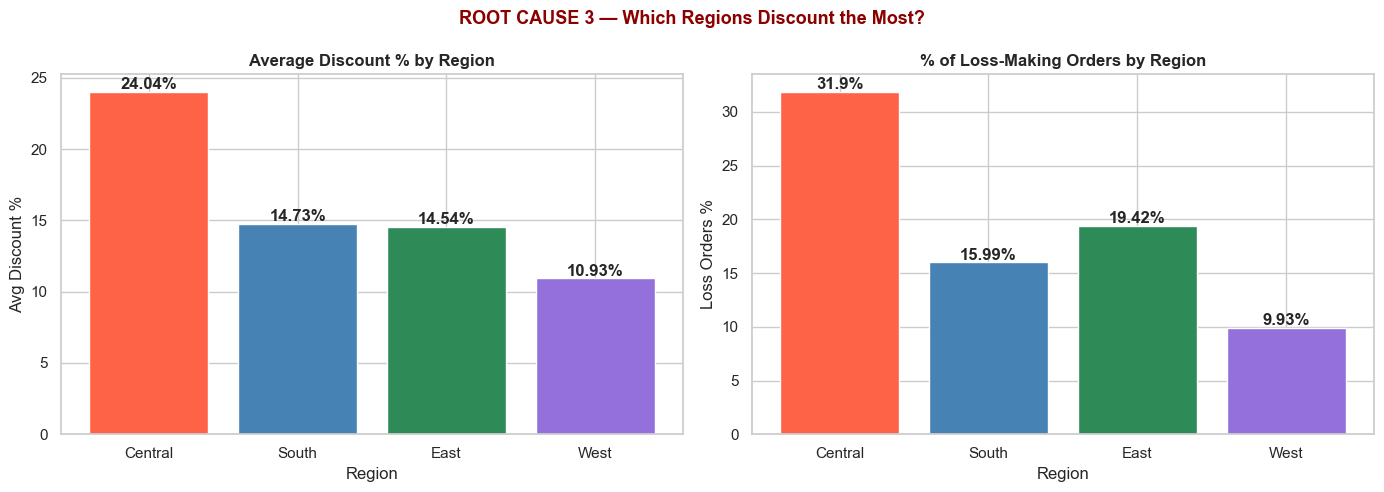

    Region  Avg_Discount_%  Loss_Order_%  Total_Profit
0  Central           24.04         31.90    39706.3625
2    South           14.73         15.99    46749.4303
1     East           14.54         19.42    91522.7800
3     West           10.93          9.93   108418.4489


In [13]:
region_discount=df.groupby('Region').agg(
    Avg_Discount=('Discount', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Loss_Orders=('Profit', lambda x: (x<0).sum()),
    Total_Orders=('Order ID', 'count')
).reset_index()
region_discount['Avg_Discount_%']=(region_discount['Avg_Discount']*100).round(2)
region_discount['Loss_Order_%']=(region_discount['Loss_Orders']/region_discount['Total_Orders']*100).round(2)
region_discount=region_discount.sort_values('Avg_Discount_%', ascending=False)
fig,axes=plt.subplots(1,2,figsize=(14, 5))

bar_colors=['tomato', 'steelblue', 'seagreen', 'mediumpurple']
axes[0].bar(region_discount['Region'], region_discount['Avg_Discount_%'], color=bar_colors)
for i, v in enumerate(region_discount['Avg_Discount_%']):
    axes[0].text(i, v+0.2, f'{v}%', ha='center', fontweight='bold')
axes[0].set_title('Average Discount % by Region', fontweight='bold')
axes[0].set_ylabel('Avg Discount %')
axes[0].set_xlabel('Region')

axes[1].bar(region_discount['Region'], region_discount['Loss_Order_%'], color=bar_colors)
for i, v in enumerate(region_discount['Loss_Order_%']):
    axes[1].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')
axes[1].set_title('% of Loss-Making Orders by Region', fontweight='bold')
axes[1].set_ylabel('Loss Orders %')
axes[1].set_xlabel('Region')

plt.suptitle('ROOT CAUSE 3 — Which Regions Discount the Most?', fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('Regional_discount.png', dpi=150)
plt.show()

print("="*55)
print(region_discount[['Region', 'Avg_Discount_%', 'Loss_Order_%', 'Total_Profit']])

#### Does discounting even help sales?

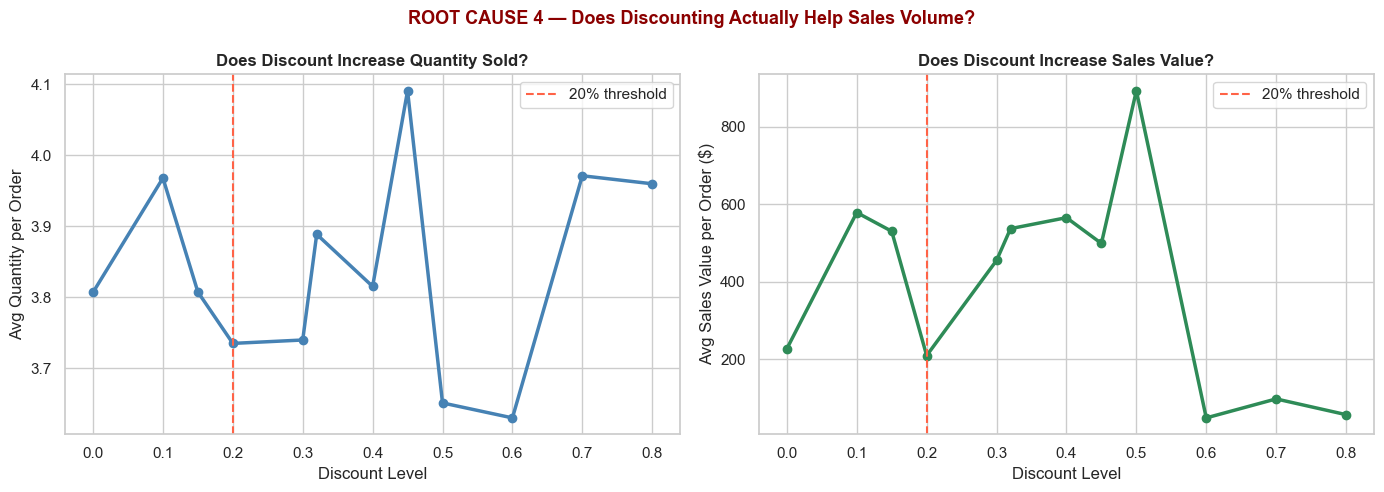

THE VERDICT — Does discounting help?
Avg quantity — Discount <20% : 3.81
Avg quantity — Discount >=20%: 3.77
Avg sales val — Discount <20% : $236.62
Avg sales val — Discount >=20%: $223.24
Avg profit — Discount <20% : $67.04
Avg profit — Discount >=20%: $-8.92


In [14]:
# Does higher discount=more quantity or higher sales value?
discount_qty=df.groupby('Discount').agg(
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit=('Profit', 'mean')
).reset_index()
fig,axes=plt.subplots(1,2,figsize=(14, 5))

# Ch 1 — Discount vs Quantity
axes[0].plot(discount_qty['Discount'], discount_qty['Avg_Quantity'], marker='o', color='steelblue', linewidth=2.5)
axes[0].axvline(0.2, color='tomato', linestyle='--', linewidth=1.5, label='20% threshold')
axes[0].set_title('Does Discount Increase Quantity Sold?', fontweight='bold')
axes[0].set_xlabel('Discount Level')
axes[0].set_ylabel('Avg Quantity per Order')
axes[0].legend()

# Ch 2 — Discount vs Avg Sales Value
axes[1].plot(discount_qty['Discount'], discount_qty['Avg_Sales'], marker='o', color='seagreen', linewidth=2.5)
axes[1].axvline(0.2, color='tomato', linestyle='--', linewidth=1.5, label='20% threshold')
axes[1].set_title('Does Discount Increase Sales Value?', fontweight='bold')
axes[1].set_xlabel('Discount Level')
axes[1].set_ylabel('Avg Sales Value per Order ($)')
axes[1].legend()

plt.suptitle('ROOT CAUSE 4 — Does Discounting Actually Help Sales Volume?', fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('Discount_volume.png', dpi=150)
plt.show()

# The verdict
high = df[df['Discount']>=0.2]
low  = df[df['Discount']<0.2]
print("="*55)
print("THE VERDICT — Does discounting help?")
print(f"Avg quantity — Discount <20% : {low['Quantity'].mean():.2f}")
print(f"Avg quantity — Discount >=20%: {high['Quantity'].mean():.2f}")
print(f"Avg sales val — Discount <20% : ${low['Sales'].mean():.2f}")
print(f"Avg sales val — Discount >=20%: ${high['Sales'].mean():.2f}")
print(f"Avg profit — Discount <20% : ${low['Profit'].mean():.2f}")
print(f"Avg profit — Discount >=20%: ${high['Profit'].mean():.2f}")
print("="*55)

#### Total financial damage quantified

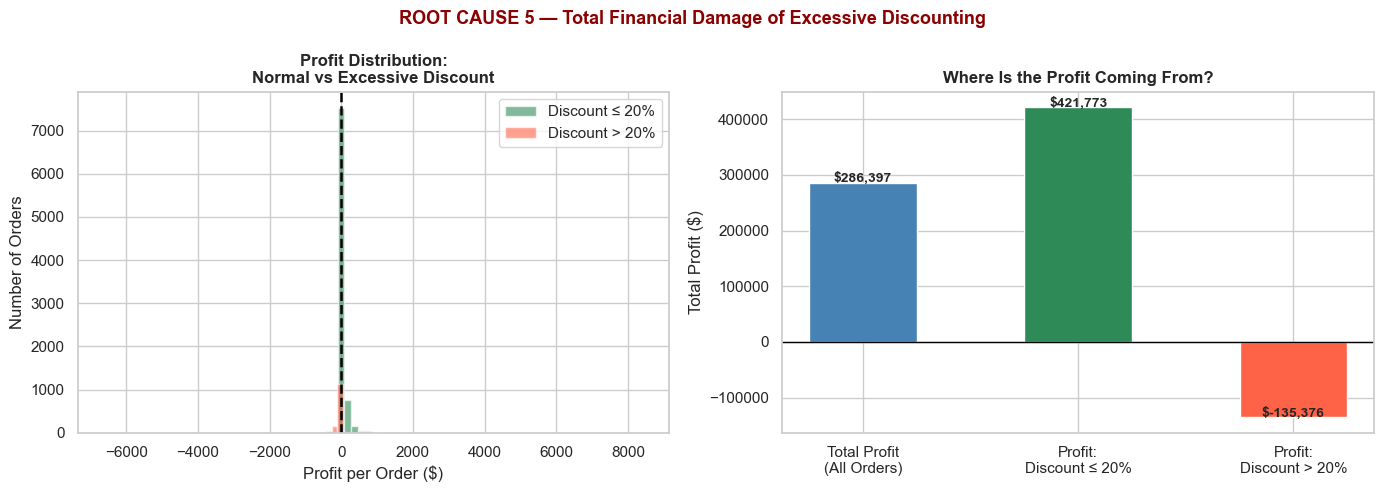

FINANCIAL IMPACT SUMMARY
Total company profit: $286,397.02
Profit — orders with disc ≤ 20%: $421,773.08
Profit — orders with disc > 20%: $-135,376.06
Total profit LOST (loss orders): $-156,131.29
Number of loss-making orders: 1871
% of orders losing money: 18.7%


In [15]:
excessive=df[df['Discount']>0.20]
normal=df[df['Discount']<=0.20]
loss_orders=df[df['Profit']<0]
fig,axes=plt.subplots(1,2,figsize=(14, 5))

# Ch 1 — Profit distribution comparison
axes[0].hist(normal['Profit'], bins=50, color='seagreen', alpha=0.6, label='Discount ≤ 20%')
axes[0].hist(excessive['Profit'], bins=50, color='tomato', alpha=0.6, label='Discount > 20%')
axes[0].axvline(0, color='black', linewidth=1.8, linestyle='--')
axes[0].set_title('Profit Distribution:\nNormal vs Excessive Discount', fontweight='bold')
axes[0].set_xlabel('Profit per Order ($)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Ch 2 — Where is the profit coming from?
labels=['Total Profit\n(All Orders)', 'Profit:\nDiscount ≤ 20%', 'Profit:\nDiscount > 20%']
values=[df['Profit'].sum(), normal['Profit'].sum(), excessive['Profit'].sum()]
bar_colors=['steelblue', 'seagreen', 'tomato']
bars=axes[1].bar(labels, values, color=bar_colors, width=0.5)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Where Is the Profit Coming From?',
                   fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1500,
        f'${val:,.0f}',
        ha='center', fontsize=10, fontweight='bold')

plt.suptitle('ROOT CAUSE 5 — Total Financial Damage of Excessive Discounting', fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.savefig('Financial_damage.png', dpi=150)
plt.show()

print("="*55)
print("FINANCIAL IMPACT SUMMARY")
print(f"Total company profit: ${df['Profit'].sum():>10,.2f}")
print(f"Profit — orders with disc ≤ 20%: ${normal['Profit'].sum():>10,.2f}")
print(f"Profit — orders with disc > 20%: ${excessive['Profit'].sum():>10,.2f}")
print(f"Total profit LOST (loss orders): ${loss_orders['Profit'].sum():>10,.2f}")
print(f"Number of loss-making orders: {len(loss_orders)}")
print(f"% of orders losing money: " f"{len(loss_orders)/len(df)*100:.1f}%")
print("="*55)

## Summary

- Threshold - Profit turns negative when discount exceeds 20% 
- Category - Furniture gets highest avg discount → lowest margin 
- Region - Central region has highest % of loss-making orders 
- Volume - Higher discounts do NOT increase quantity or sales value 
- Damage - Orders with >20% discount are generating net losses for the company 

##### Final Conclusion:
The company believes giving higher discounts drives more volume and 
compensates through scale. The data DISPROVES this completely.

- Higher discounts do NOT meaningfully increase quantity sold
- Higher discounts do NOT increase average order value
- They simply reduce profit — and beyond 20%, they create losses

##### This is 100% controllable. No external factor is responsible.
##### Management can fix this immediately — which leads to Phase 5.